In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer , WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel , TfidfModel
from sklearn.feature_extraction.text import CountVectorizer , TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report


In [4]:
plt.rcParams['figure.figsize']=(12 , 8)
default_plot_colour="#00bfbf"

In [5]:
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


<Axes: xlabel='fake_or_factual'>

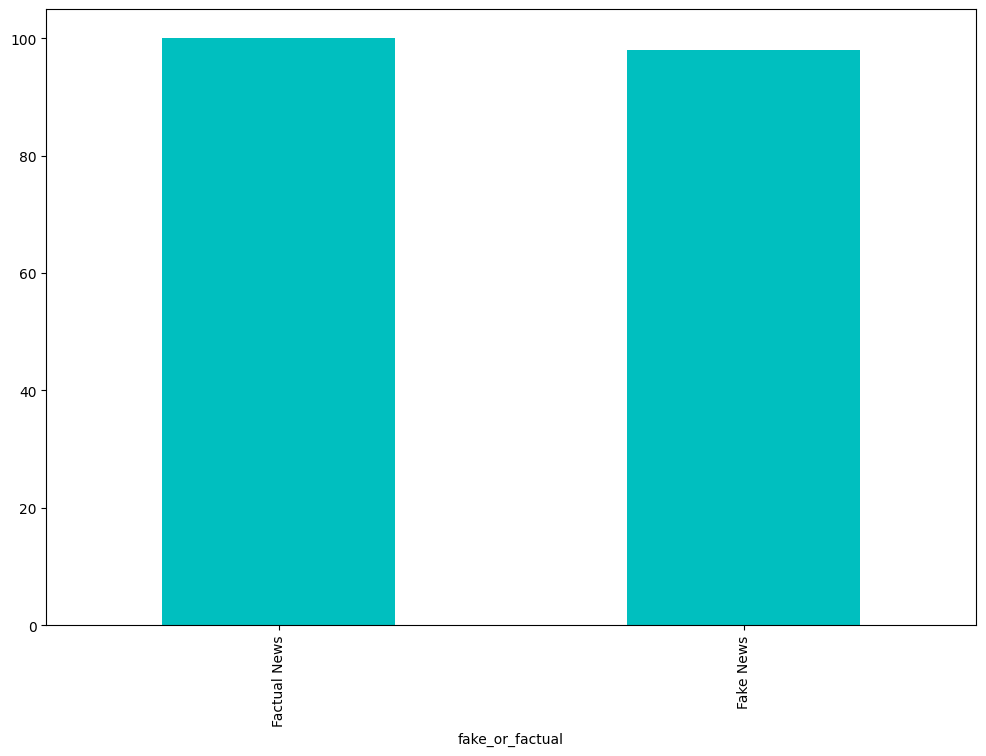

In [6]:
data['fake_or_factual'].value_counts().plot.bar(color=default_plot_colour)

In [7]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [8]:
nlp = spacy.load("en_core_web_sm")

In [9]:
fake_news = data[(data['fake_or_factual']) == "Fake News"]
fact_news = data[(data['fake_or_factual']) == "Factual News"]

In [10]:
fake_news.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
5,Maxine Waters Makes Teens Chant ‘Impeach 45′ a...,Shame on Teen Vogue! Maxine Waters was a guest...,"Dec 10, 2017",Fake News
6,Jay Carney Let It Slip That He Knows Who Obam...,Former White House Press Secretary in the Obam...,"February 10, 2016",Fake News


In [11]:
fake_spacydoc = list(nlp.pipe(fake_news['text']))
fact_spacydoc = list(nlp.pipe(fact_news['text']))

In [12]:
def extract_token_tags (doc:spacy.tokens.doc.Doc):
    return [(i.text , i.ent_type_ , i.pos_) for i in doc]

In [13]:
columns = ['token' , 'ner_tag' , 'pos_tag']
fake_tagdf = []

In [14]:
for ix , doc in enumerate (fake_spacydoc):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns= columns
    fake_tagdf.append(tags)

In [15]:
fake_tagdf = pd.concat(fake_tagdf)

In [16]:
fake_tagdf

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
743,.,,PUNCT
744,Via,,PROPN
745,:,,PUNCT
746,Campus,PERSON,PROPN


In [17]:
fact_tagdf = []

for ix , doc in enumerate (fact_spacydoc):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns= columns
    fact_tagdf.append(tags)

In [18]:
fact_tagdf = pd.concat(fact_tagdf)

In [19]:
pos_fake_count = fake_tagdf.groupby(['token' , 'pos_tag']).size().reset_index(name= 'counts').sort_values(by='counts' ,ascending=False )

In [20]:
pos_fake_count

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
...,...,...,...
3770,detectives,VERB,1
3769,detective,NOUN,1
3768,detained,VERB,1
3766,detail,NOUN,1


In [21]:
pos_fact_count = fact_tagdf.groupby(['token' , 'pos_tag']).size().reset_index(name= 'counts').sort_values(by='counts' ,ascending=False )

In [22]:
pos_fake_count.groupby(['pos_tag'])['token'].count().sort_values(ascending=False )

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [23]:
pos_fake_count[pos_fake_count.pos_tag == "NOUN"].head(15)

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [24]:
pos_fact_count.groupby(['pos_tag'])['token'].count().sort_values(ascending=False )

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

In [25]:
pos_fact_count[pos_fact_count.pos_tag == "NOUN"].head(15)

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


In [26]:
top_entities_fake = fake_tagdf[fake_tagdf['ner_tag'] != ""].groupby(['token' , 'ner_tag']).size().reset_index(name="counts").sort_values(by='counts' , ascending=False)

In [27]:
top_entities_fake.head()

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75


In [28]:
top_entities_fact = fact_tagdf[fact_tagdf['ner_tag'] != ""].groupby(['token' , 'ner_tag']).size().reset_index(name="counts").sort_values(by='counts' , ascending=False)

In [29]:
top_entities_fake.head()

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75


In [30]:
ner_palette = {
    'ORG' : sns.color_palette("Set2").as_hex()[0],
    'GPE' : sns.color_palette("Set2").as_hex()[1],
    'NORP' : sns.color_palette("Set2").as_hex()[2],
    'PERSON' : sns.color_palette("Set2").as_hex()[3],
    'DATE' : sns.color_palette("Set2").as_hex()[4],
    'CARDINAL' : sns.color_palette("Set2").as_hex()[5],
    'PERCENT' : sns.color_palette("Set2").as_hex()[6],
}

[Text(0.5, 1.0, 'most common named entity in fake news')]

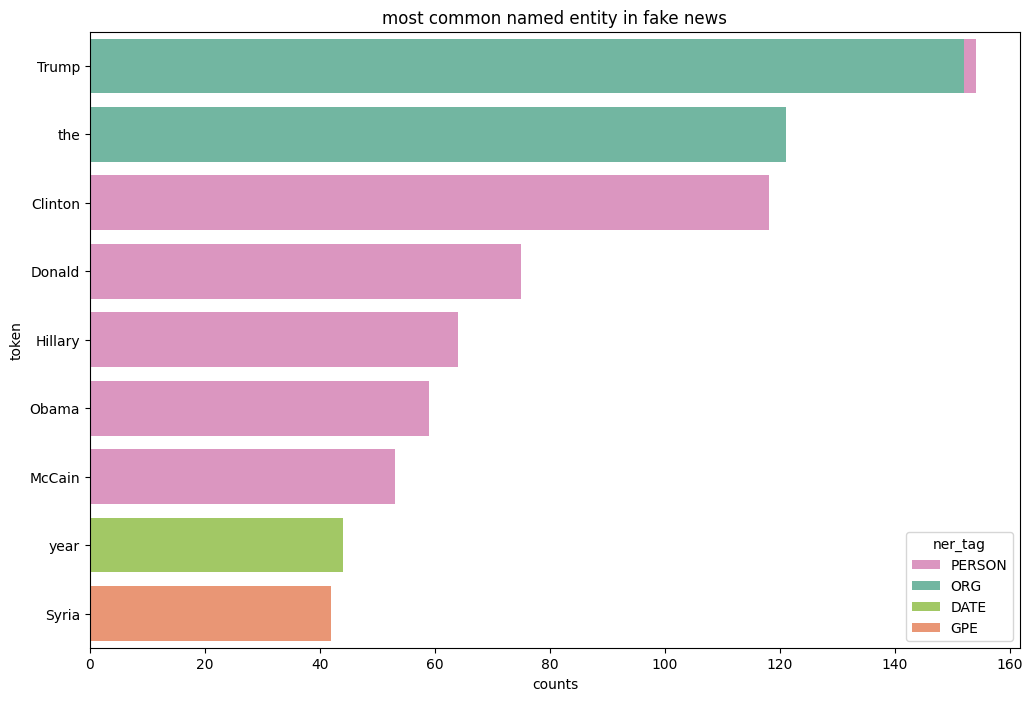

In [31]:
sns.barplot(data=top_entities_fake[:10],
            x='counts',
            y='token',
            palette=ner_palette,
            hue='ner_tag',
            orient='h',
            dodge=False ,
            ).set(title="most common named entity in fake news")

[Text(0.5, 1.0, 'most common named entity in fact news')]

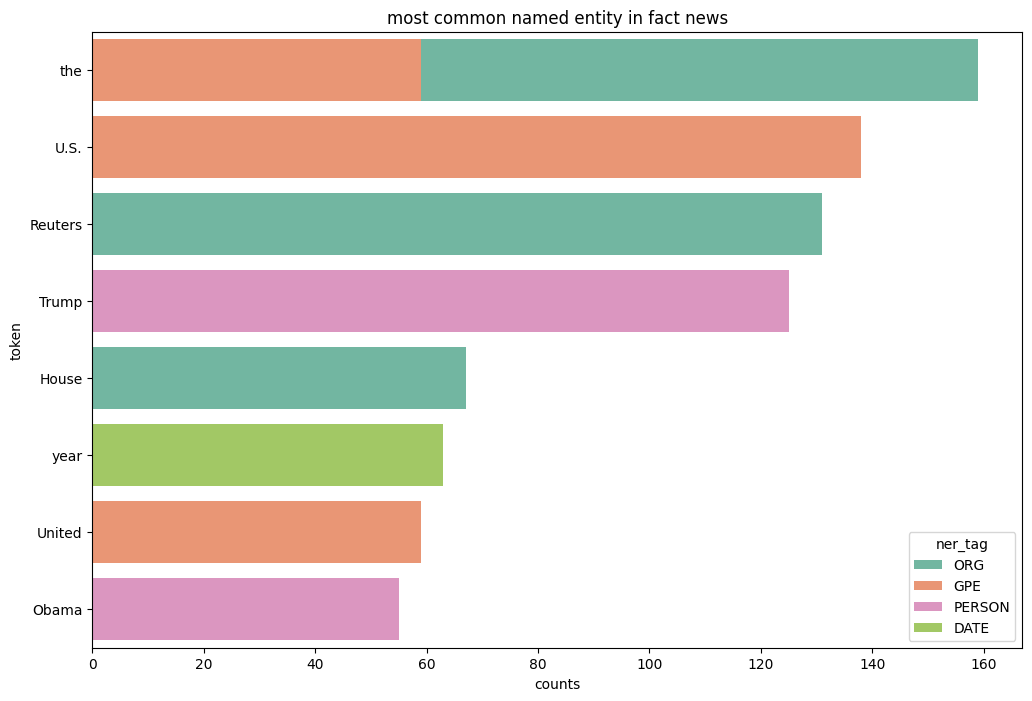

In [32]:
sns.barplot(data=top_entities_fact[:10],
            x='counts',
            y='token',
            palette=ner_palette,
            hue='ner_tag',
            orient='h',
            dodge=False ,
            ).set(title="most common named entity in fact news")

# Text Preprocessing

In [33]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [34]:
data['text_clean']= data['text'].apply(lambda x: re.sub(r"^[^-]*-\s*" , "" , x))

In [35]:
data['text_clean'] = data["text_clean"].str.lower()

In [36]:
data['text_clean'] = data['text_clean'].apply(lambda x : re.sub(r"([^\w\s])" , "" , x))

In [37]:
en_stopword = stopwords.words("english")
data["text_clean"] = data["text_clean"].apply(lambda x: ' '.join([word for word in x.split() if word not in en_stopword]))

In [38]:

data['text_clean'] = data["text_clean"].apply(lambda x : word_tokenize(x))

In [39]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data["text_clean"].apply(lambda x : [lemmatizer.lemmatize(word) for word in x])

In [40]:
token_sum = sum(data["text_clean"] , [])

In [ ]:
unigram = pd.Series(nltk.ngrams(token_sum , 1)).value_counts()

In [44]:
print(unigram[:10])

0         (yearold,)
1    (oscarwinning,)
2         (actress,)
3       (described,)
4         (meeting,)
5       (16yearold,)
6            (girl,)
7      (apparently,)
8           (given,)
9           (birth,)
dtype: object


In [45]:
bigram = pd.Series(nltk.ngrams(token_sum , 2)).value_counts()
print(bigram[:10])

(donald, trump)        92
(united, state)        80
(white, house)         72
(president, donald)    42
(hillary, clinton)     31
(new, york)            31
(image, via)           29
(supreme, court)       29
(official, said)       26
(food, stamp)          24
Name: count, dtype: int64


# sentiment

In [50]:
vader_sentiment = SentimentIntensityAnalyzer()

In [61]:
data['vader_sentiment_score'] = data['text'].apply(lambda x : vader_sentiment.polarity_scores(x)['compound'])

In [62]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [63]:
bins= [-1 , -0.1 , 0.1 , 1]
names = ['negative' , 'neutral' , 'positive']



In [64]:
data['vader_sentiment_label'] = pd.cut (data['vader_sentiment_score'] , bins=bins , labels=names)

In [65]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

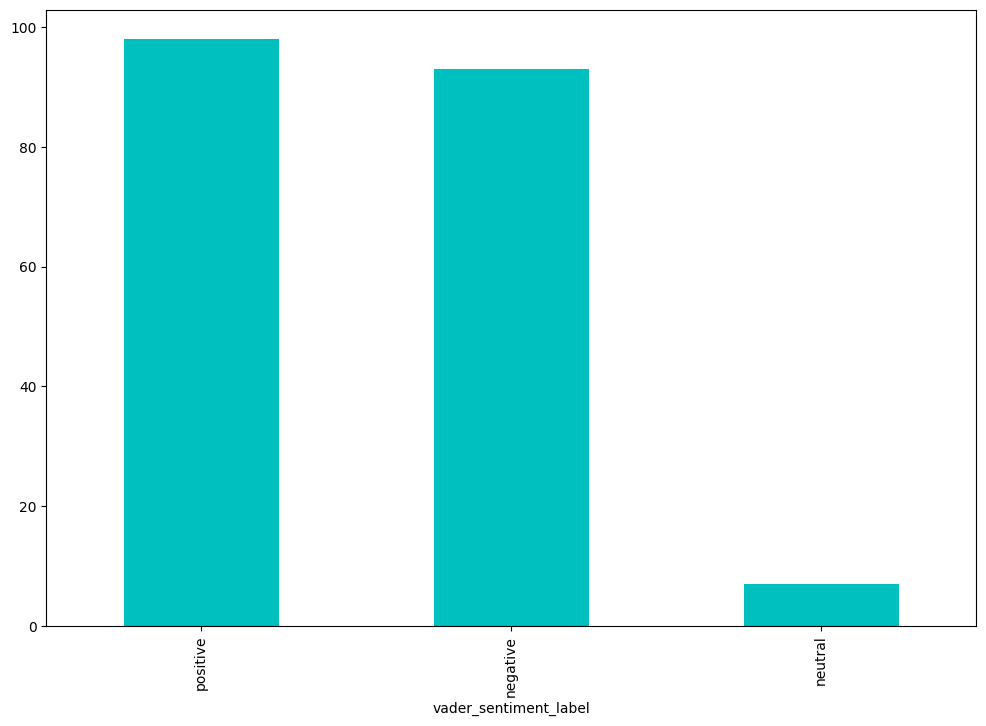

In [66]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

C:\Users\ECO\AppData\Local\Temp\ipykernel_37352\2749409554.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'sentiment by news type')]

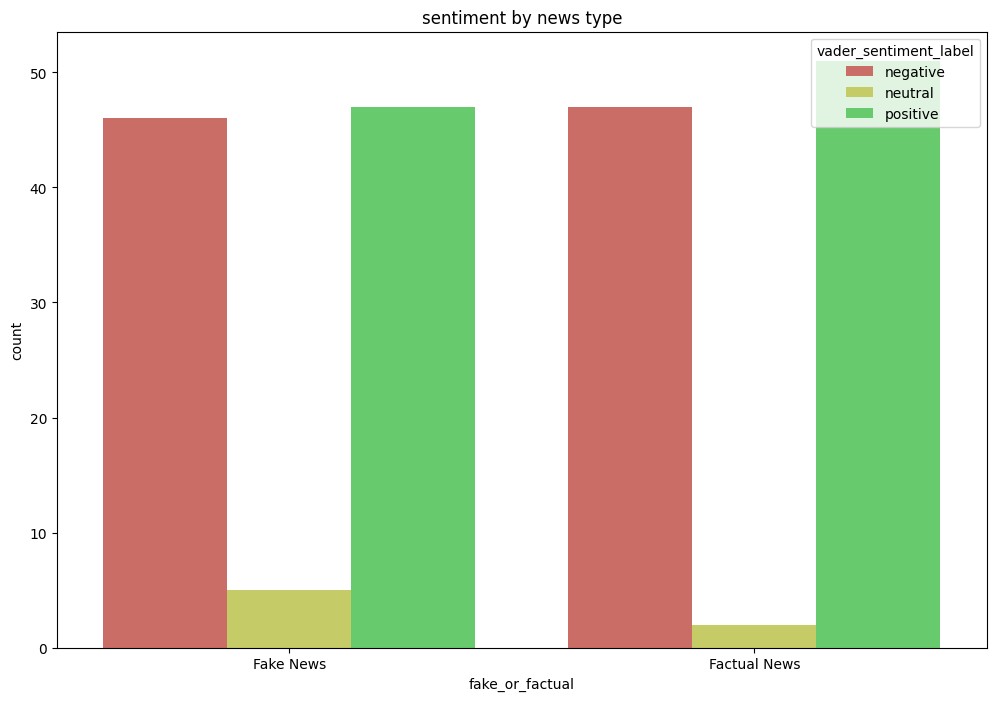

In [67]:
sns.countplot(
    x='fake_or_factual',
    hue='vader_sentiment_label',
    palette=sns.color_palette("hls"),
    data=data
).set(title="sentiment by news type")

# topic modeling

In [79]:
fake_new_data = data[data["fake_or_factual"] == "Fake News"]['text_clean'].reset_index(drop=True)

In [80]:
fake_new_data.head()

0    [yearold, oscarwinning, actress, described, me...
1    [buried, trump, bonkers, interview, new, york,...
2    [woman, make, 50, percent, country, grossly, u...
3    [58, resolution, consider, move, week, fox, ne...
4    [inneck, race, must, pretty, antsy, though, un...
Name: text_clean, dtype: object

In [81]:
dictionary_fake = corpora.Dictionary(fake_new_data)

In [82]:
bag_of_words = [dictionary_fake.doc2bow(text) for text in fake_new_data]

In [92]:
coherence_value = []
model = []

min_topic = 2
max_topic = 11

for num_topic in range(min_topic , max_topic+1):
    lda_model = gensim.models.LdaModel(bag_of_words , num_topics=num_topic , id2word=dictionary_fake , random_state=7 )
    model.append(lda_model)
    coherence_model = CoherenceModel(model=lda_model , texts=fake_new_data , dictionary= dictionary_fake , coherence='c_v')
    coherence_value.append(coherence_model.get_coherence())


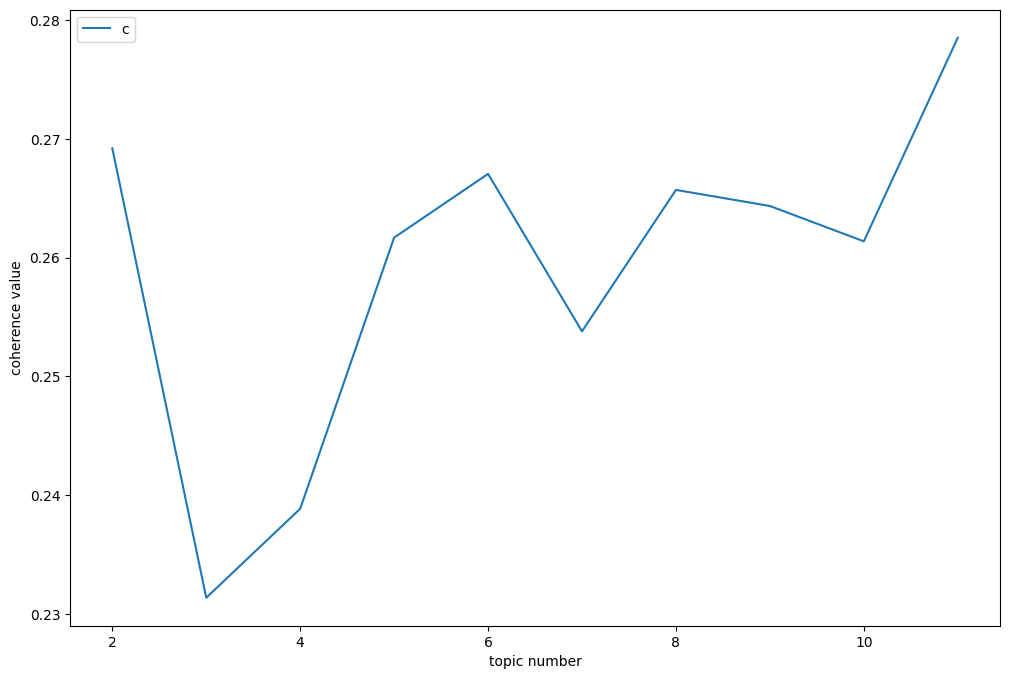

In [93]:
plt.plot(range(min_topic , max_topic+1) , coherence_value)
plt.xlabel("topic number")
plt.ylabel("coherence value")
plt.legend("coherence_value" , loc='best')
plt.show()

In [96]:
def tfidf_corpus (corpus_fake):
    tfidf = TfidfModel(corpus_fake , normalize=True)
    corpus_tfidf = tfidf[corpus_fake]
    return corpus_tfidf

In [100]:
def get_coherence_score (corpus , dictionary_fake , text ,  min_topic , max_topic):
    coherence_value = []
    model = []

    for num_topic in range(min_topic , max_topic+1):
        lsi_model =LsiModel(corpus , num_topics=num_topic , id2word=dictionary_fake , random_seed=7 )
        model.append(lsi_model)
        coherence_model = CoherenceModel(model=lsi_model , texts=text , dictionary= dictionary_fake , coherence='c_v')
        coherence_value.append(coherence_model.get_coherence())

    plt.plot(range(min_topic , max_topic+1) , coherence_value)
    plt.xlabel("topic number")
    plt.ylabel("coherence value")
    plt.legend("coherence_value" , loc='best')
    plt.show()

    

In [98]:
tfidf_corpus(bag_of_words)

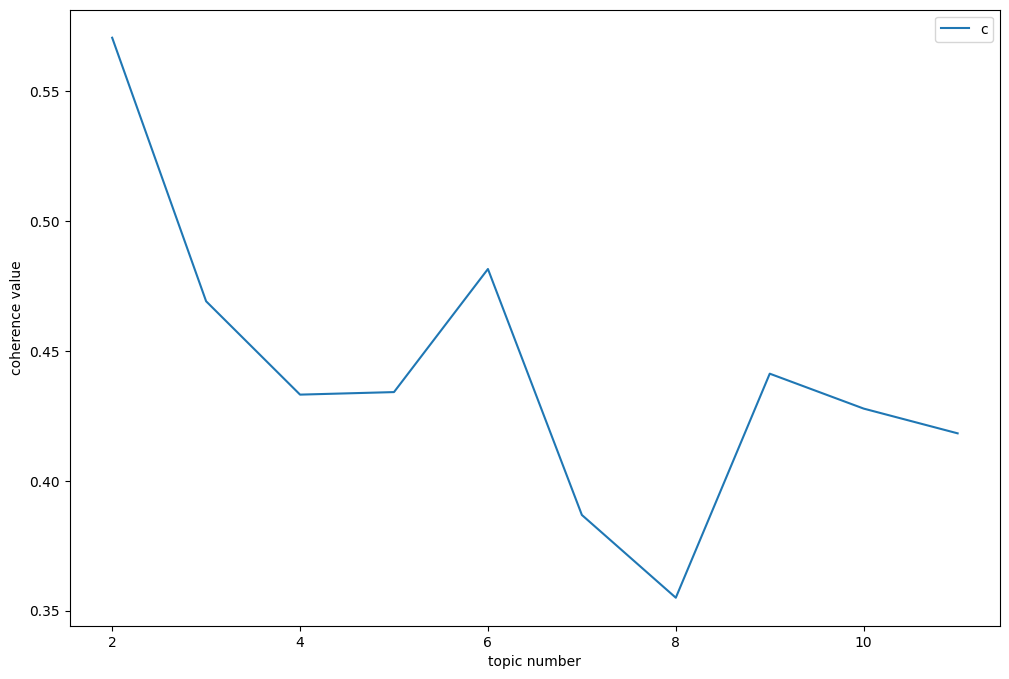

In [101]:
get_coherence_score(bag_of_words , dictionary_fake , fake_new_data , 2 ,11)

In [102]:
lsi_model =LsiModel(bag_of_words , 6 , dictionary_fake , random_seed=7 )

In [104]:
lsi_model.print_topics()

[(0,
  '-0.448*"mccain" + -0.324*"syria" + -0.219*"trump" + -0.190*"u" + -0.150*"one" + -0.116*"john" + -0.112*"terrorist" + -0.110*"people" + -0.106*"would" + -0.105*"war"'),
 (1,
  '-0.686*"trump" + 0.284*"mccain" + 0.200*"syria" + -0.126*"republican" + -0.117*"president" + -0.117*"supporter" + -0.105*"said" + -0.088*"woman" + -0.084*"clinton" + -0.084*"student"'),
 (2,
  '0.426*"food" + 0.407*"stamp" + 0.336*"million" + 0.258*"fraud" + 0.183*"store" + -0.181*"trump" + 0.151*"money" + 0.148*"benefit" + 0.144*"program" + 0.121*"back"'),
 (3,
  '0.334*"trump" + -0.239*"law" + -0.238*"would" + -0.207*"adultery" + -0.190*"clinton" + -0.187*"death" + -0.173*"woman" + -0.160*"state" + 0.151*"mccain" + -0.151*"anderson"'),
 (4,
  '0.329*"clinton" + -0.268*"adultery" + -0.245*"law" + -0.222*"death" + -0.196*"anderson" + 0.159*"rich" + 0.152*"email" + 0.147*"official" + -0.136*"would" + 0.133*"time"'),
 (5,
  '-0.530*"student" + -0.248*"campus" + -0.177*"career" + 0.164*"trump" + -0.163*"undo

In [162]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [163]:
x = [','.join(map(str , l)) for l in data['text_clean']]
y = data['fake_or_factual']

In [164]:
convec = CountVectorizer()
convec_fit = convec.fit_transform(x)
bag_of_words = pd.DataFrame(convec_fit.toarray(), columns = convec.get_feature_names_out())


In [165]:
(x_train , x_test , y_train , y_test) = train_test_split(bag_of_words , y, test_size=0.3)

In [172]:
lr = LogisticRegression(random_state=0)

In [173]:
lr.fit(x_train , y_train)

LogisticRegression(random_state=0)

In [174]:
print(x_train.shape)
print(y_train.shape)

(138, 8552)
(138,)


In [175]:
y_prid = lr.predict(x_test)

In [176]:
accuracy_score(y_prid, y_test)

0.8166666666666667

In [171]:
from sklearn.linear_model import SGDClassifier

In [157]:
svm = SGDClassifier().fit(x_train, y_train)

In [160]:
y_prid_svm = svm.predict(x_test)

In [161]:
accuracy_score(y_prid_svm, y_test)

0.8